# Energy Consumption Prediction for Multi-Device Edge AI Deployment

This notebook trains and evaluates energy prediction models for Jetson Nano and Raspberry Pi 5 edge AI devices.

**Dataset:** 613 samples (360 Jetson Nano + 253 Raspberry Pi 5), 45+ features

**Goals:**
- Unified model: MAPE < 16%, R² > 0.70
- Device-specific: Jetson MAPE < 18%, RPi5 MAPE < 12%
- Hyperparameter tuning with RandomizedSearchCV
- Stacking ensemble
- Professional IEEE-style figures

## 1. Imports & Configuration

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pickle
import scipy.stats as stats
import seaborn as sns
from datetime import datetime, timezone

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
    print("XGBoost available.")
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not available — skipping.")

warnings.filterwarnings("ignore")

# IEEE-paper style
plt.rcParams.update({
    "font.size": 9,
    "font.family": "serif",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

JETSON_COLOR = "#2563eb"
RPI5_COLOR   = "#16a34a"
DEVICE_PALETTE = {"Jetson Nano": JETSON_COLOR, "Raspberry Pi 5": RPI5_COLOR}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
FIGURE_DIR   = ARTIFACT_DIR / "report_figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Artifact dir : {ARTIFACT_DIR}")
print(f"Figure dir   : {FIGURE_DIR}")

XGBoost available.
Project root : D:\KLTN\DACN_Energy_consumption\ml-controller
Artifact dir : D:\KLTN\DACN_Energy_consumption\ml-controller\artifacts
Figure dir   : D:\KLTN\DACN_Energy_consumption\ml-controller\artifacts\report_figures


## 2. Data Loading & Feature Engineering

In [2]:
FAMILY_PATTERNS = [
    "convnextv2", "efficientformer", "efficientvit", "mobilenet", "efficientnet",
    "convnext", "coatnet", "shufflenet", "squeezenet", "ghostnet", "mnasnet",
    "densenet", "regnet", "resnet", "seresnet", "deit", "beit", "crossvit",
    "convit", "maxvit", "fastvit", "mobilevit", "edgenext", "coat", "cait",
    "xcit", "swin", "vit", "vgg", "inception", "rexnet", "fbnetv", "lcnet",
    "tinynet", "hrnet", "darknet", "dla", "dpn",
]

TRANSFORMER_TOKENS = {"vit", "deit", "beit", "swin", "xcit", "crossvit", "convit", "cait", "maxvit", "coatnet", "coat"}
MOBILE_EDGE_TOKENS  = {"mobilenet", "mobilevit", "ghostnet", "mnasnet", "shufflenet", "fbnetv", "rexnet", "lcnet"}
EFFICIENT_TOKENS    = {"efficientnet", "efficientformer", "efficientvit", "tinynet", "edgenext", "fastvit"}
CNN_BACKBONE_TOKENS = {"resnet", "seresnet", "regnet", "densenet", "vgg", "inception", "convnext", "convnextv2", "hrnet"}


def infer_model_family(name):
    n = str(name or "").lower()
    for p in FAMILY_PATTERNS:
        if p in n:
            return p
    return n.split("_")[0][:8] or "other"


def infer_function_group(name):
    n = str(name or "").lower()
    if any(t in n for t in TRANSFORMER_TOKENS):
        return "vision_transformer"
    if any(t in n for t in MOBILE_EDGE_TOKENS):
        return "mobile_edge"
    if any(t in n for t in EFFICIENT_TOKENS):
        return "efficient_edge"
    if any(t in n for t in CNN_BACKBONE_TOKENS):
        return "cnn_backbone"
    return "general_vision"


def parse_resolution(val):
    text = str(val or "").lower().replace("[","").replace("]","").replace("(","").replace(")","")
    text = text.replace(",", "x").replace(" ", "")
    parts = [p for p in text.split("x") if p]
    if len(parts) < 2:
        return np.nan, np.nan
    try:
        return float(parts[-2]), float(parts[-1])
    except ValueError:
        return np.nan, np.nan


def safe_div(a, b, eps=1e-9):
    b_arr = np.where(np.abs(np.asarray(b, float)) < eps, np.nan, np.asarray(b, float))
    return np.asarray(a, float) / b_arr


def engineer_features(df):
    """Add all derived/interaction features to df in-place and return it."""
    # parse resolution
    wh = df["input_resolution_actual"].map(parse_resolution)
    df["input_width"]     = wh.map(lambda x: x[0])
    df["input_height"]    = wh.map(lambda x: x[1])
    df["input_pixels_mp"] = df["input_width"] * df["input_height"] / 1e6
    df["aspect_ratio"]    = safe_div(df["input_width"], df["input_height"])

    # duration columns (Jetson may lack them)
    for col in ("duration_run1_s", "duration_run2_s", "duration_run3_s"):
        if col not in df.columns:
            df[col] = np.nan
    dur_cols = [c for c in df.columns if c.startswith("duration_run")]
    df["duration_mean_s"] = df[dur_cols].mean(axis=1)
    df["duration_std_s"]  = df[dur_cols].std(axis=1, ddof=0)

    # ratio features
    df["params_per_mb"]          = safe_div(df["params_m"],              df["size_mb"] + 1e-9)
    df["gflops_per_param"]       = safe_div(df["gflops"],                df["params_m"] + 1e-9)
    df["gmacs_per_param"]        = safe_div(df["gmacs"],                 df["params_m"] + 1e-9)
    df["throughput_per_param"]   = safe_div(df["throughput_iter_per_s"], df["params_m"] + 1e-9)
    df["latency_per_param"]      = safe_div(df["latency_avg_s"],         df["params_m"] + 1e-9)
    df["latency_per_gflop"]      = safe_div(df["latency_avg_s"],         df["gflops"] + 1e-9)
    df["compute_to_memory_ratio"]= safe_div(df["gflops"],                df["size_mb"] + 1e-9)
    df["throughput_x_pixels"]    = df["throughput_iter_per_s"] * df["input_pixels_mp"].fillna(0)
    df["latency_x_params"]       = df["latency_avg_s"] * df["params_m"]
    df["latency_x_gflops"]       = df["latency_avg_s"] * df["gflops"]
    df["complexity_index"]       = (
        np.log1p(df["params_m"].clip(lower=0))
        * np.log1p(df["gflops"].clip(lower=0))
        * np.log1p(df["size_mb"].clip(lower=0))
    )
    df["batch_run_time_s"]       = df["latency_avg_s"] * df["runs"]

    # ---- NEW polynomial / advanced interaction features ----
    df["latency_sq"]             = df["latency_avg_s"] ** 2
    df["params_sq"]              = df["params_m"] ** 2
    df["gflops_sq"]              = df["gflops"] ** 2
    df["latency_cb"]             = df["latency_avg_s"] ** 3   # cube for heavy tails
    df["sqrt_latency"]           = np.sqrt(df["latency_avg_s"].clip(lower=0))
    df["sqrt_params"]            = np.sqrt(df["params_m"].clip(lower=0))
    df["sqrt_gflops"]            = np.sqrt(df["gflops"].clip(lower=0))
    df["log_latency"]            = np.log1p(df["latency_avg_s"].clip(lower=0))
    df["log_params"]             = np.log1p(df["params_m"].clip(lower=0))
    df["log_gflops"]             = np.log1p(df["gflops"].clip(lower=0))
    df["log_size_mb"]            = np.log1p(df["size_mb"].clip(lower=0))
    df["log_complexity"]         = np.log1p(df["complexity_index"].clip(lower=0))
    df["log_latency_x_log_params"] = df["log_latency"] * df["log_params"]
    df["log_latency_x_log_gflops"] = df["log_latency"] * df["log_gflops"]
    df["log_params_x_log_gflops"]  = df["log_params"]  * df["log_gflops"]
    df["latency_gflops_ratio"]   = safe_div(df["latency_avg_s"], df["gflops"] + 1e-9)
    df["energy_proxy"]           = df["latency_avg_s"] * df["params_m"] * df["gflops"]  # rough proxy
    df["log_energy_proxy"]       = np.log1p(df["energy_proxy"].clip(lower=0))

    # flag features
    df["is_transformer_like"]    = df["function_group"].eq("vision_transformer").astype(int)
    df["is_mobile_optimized"]    = df["function_group"].isin({"mobile_edge", "efficient_edge"}).astype(int)

    return df


def load_dataset(rpi_path, jetson_path):
    rpi = pd.read_csv(rpi_path)
    rpi["device_name"]   = "Raspberry Pi 5"
    rpi["device_type"]   = "raspberry_pi5"
    rpi["device_family"] = "cpu_edge"

    jet = pd.read_csv(jetson_path)
    jet["device_name"]   = "Jetson Nano"
    jet["device_type"]   = "jetson_nano"
    jet["device_family"] = "gpu_edge"

    df = pd.concat([rpi, jet], ignore_index=True)
    df["model_family"]   = df["model"].map(infer_model_family)
    df["function_group"] = df["model"].map(infer_function_group)
    df = engineer_features(df)
    return df


rpi_path    = DATA_DIR / "253_models_benchmark_rpi5.csv"
jetson_path = DATA_DIR / "360_models_benchmark_jetson.csv"
df = load_dataset(rpi_path, jetson_path)

print(f"Combined shape: {df.shape}")
print("Device counts:")
print(df["device_name"].value_counts().to_string())
print("\nTarget variable summary:")
print(df["energy_avg_mwh"].describe().round(3).to_string())

Combined shape: (613, 62)
Device counts:
device_name
Jetson Nano       360
Raspberry Pi 5    253

Target variable summary:
count      613.000
mean       208.755
std        694.312
min          2.391
25%         22.269
50%         51.587
75%        128.933
max      11736.409


## 3. Feature Column Setup

In [3]:
TARGET_COL = "energy_avg_mwh"

EXCLUDE_COLS = {
    "model", "energy_avg_mwh", "energy_std_mwh",
    "energy_run1_mwh", "energy_run2_mwh", "energy_run3_mwh",
    "input_size", "input_resolution_actual", "device_name",
    "dataset_source", "stratify_label",
    # raw proxies already encoded as logs
    "energy_proxy",
}

NUMERIC_FEATURES = [
    c for c in df.columns
    if c not in EXCLUDE_COLS
    and pd.api.types.is_numeric_dtype(df[c])
    and c != TARGET_COL
]

CATEGORICAL_FEATURES = [
    c for c in ("device_type", "device_family", "model_family", "function_group")
    if c in df.columns
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Numeric features   : {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total features     : {len(FEATURE_COLUMNS)}")
print("\nNumeric features:")
print(NUMERIC_FEATURES)

Numeric features   : 48
Categorical features: 4
Total features     : 52

Numeric features:
['params_m', 'gflops', 'gmacs', 'size_mb', 'runs', 'latency_avg_s', 'latency_std_s', 'throughput_iter_per_s', 'duration_run1_s', 'duration_run2_s', 'duration_run3_s', 'input_width', 'input_height', 'input_pixels_mp', 'aspect_ratio', 'duration_mean_s', 'duration_std_s', 'params_per_mb', 'gflops_per_param', 'gmacs_per_param', 'throughput_per_param', 'latency_per_param', 'latency_per_gflop', 'compute_to_memory_ratio', 'throughput_x_pixels', 'latency_x_params', 'latency_x_gflops', 'complexity_index', 'batch_run_time_s', 'latency_sq', 'params_sq', 'gflops_sq', 'latency_cb', 'sqrt_latency', 'sqrt_params', 'sqrt_gflops', 'log_latency', 'log_params', 'log_gflops', 'log_size_mb', 'log_complexity', 'log_latency_x_log_params', 'log_latency_x_log_gflops', 'log_params_x_log_gflops', 'latency_gflops_ratio', 'log_energy_proxy', 'is_transformer_like', 'is_mobile_optimized']


## 4. EDA — Figure 1: Energy Distribution by Device

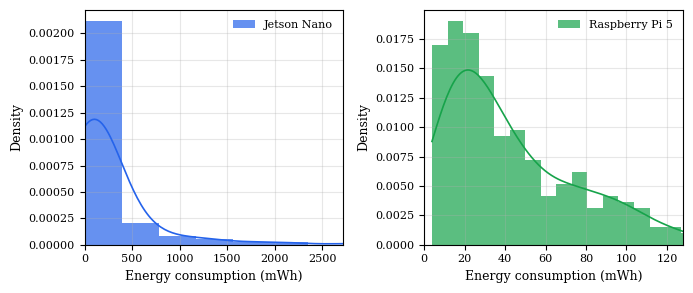

Saved: fig_eda_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

for ax, device, color in zip(axes, ["Jetson Nano", "Raspberry Pi 5"], [JETSON_COLOR, RPI5_COLOR]):
    sub = df[df["device_name"] == device]["energy_avg_mwh"]
    ax.hist(sub, bins=30, color=color, alpha=0.7, density=True, label=device)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(sub)
    xs = np.linspace(sub.min(), sub.quantile(0.99), 200)
    ax.plot(xs, kde(xs), color=color, linewidth=1.2)
    ax.set_xlabel("Energy consumption (mWh)")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    ax.set_xlim(left=0, right=sub.quantile(0.98))

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig_eda_distribution.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_eda_distribution.png")

## 5. EDA — Figure 5: Correlation Heatmap

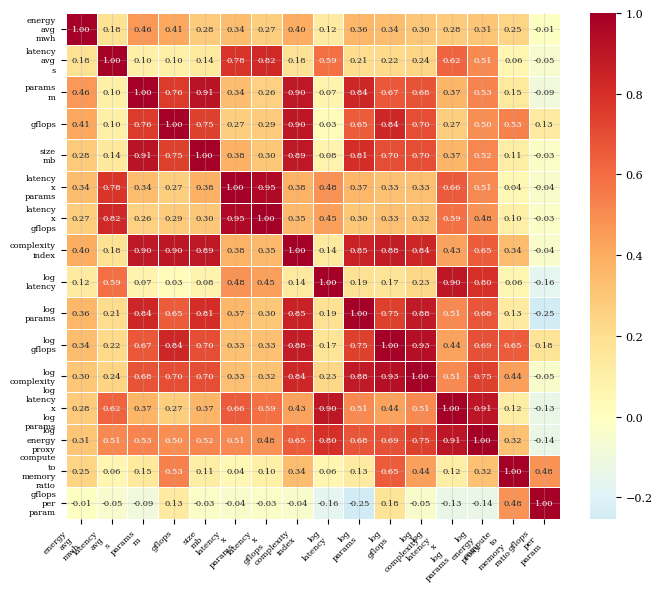

Saved: fig_correlation.png

Top correlations with energy:
energy_avg_mwh              1.000000
params_m                    0.462405
gflops                      0.413934
complexity_index            0.403324
log_params                  0.360144
latency_x_params            0.340315
log_gflops                  0.335588
log_energy_proxy            0.305948
log_complexity              0.302361
size_mb                     0.284041
log_latency_x_log_params    0.283042
latency_x_gflops            0.272048
compute_to_memory_ratio     0.250665
latency_avg_s               0.181062
log_latency                 0.124862
gflops_per_param           -0.010870


In [5]:
CORR_FEATURES = [
    "energy_avg_mwh", "latency_avg_s", "params_m", "gflops", "size_mb",
    "latency_x_params", "latency_x_gflops", "complexity_index",
    "log_latency", "log_params", "log_gflops", "log_complexity",
    "log_latency_x_log_params", "log_energy_proxy",
    "compute_to_memory_ratio", "gflops_per_param",
]
# keep only those that actually exist
CORR_FEATURES = [c for c in CORR_FEATURES if c in df.columns]

corr_mat = df[CORR_FEATURES].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_mat, annot=True, fmt=".2f", cmap="RdYlBu_r",
    center=0, linewidths=0.4, ax=ax,
    annot_kws={"size": 6},
    xticklabels=[c.replace("_", "\n") for c in CORR_FEATURES],
    yticklabels=[c.replace("_", "\n") for c in CORR_FEATURES],
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig_correlation.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_correlation.png")

print("\nTop correlations with energy:")
print(corr_mat["energy_avg_mwh"].sort_values(ascending=False).to_string())

## 6. Train / Test Split (Stratified)

In [6]:
def make_stratify_labels(frame, target_col=TARGET_COL, bins=6):
    for n_bins in range(bins, 1, -1):
        try:
            qbins = pd.qcut(frame[target_col], q=n_bins, duplicates="drop")
            labels = frame["device_type"].astype(str) + "__" + qbins.astype(str)
            if labels.value_counts().min() >= 2:
                return labels
        except Exception:
            continue
    return frame["device_type"].astype(str)


strat_labels = make_stratify_labels(df)
train_idx, test_idx = train_test_split(
    df.index.to_numpy(), test_size=0.2,
    random_state=RANDOM_STATE, stratify=strat_labels
)

train_df = df.loc[train_idx].copy()
test_df  = df.loc[test_idx].copy()
train_df["stratify_label"] = strat_labels.loc[train_idx].values
test_df["stratify_label"]  = strat_labels.loc[test_idx].values

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COL].values
X_test  = test_df[FEATURE_COLUMNS]
y_test  = test_df[TARGET_COL].values

print(f"Train: {train_df.shape}  Test: {test_df.shape}")
print("Device split in test:")
print(test_df["device_name"].value_counts().to_string())

Train: (490, 63)  Test: (123, 63)
Device split in test:
device_name
Jetson Nano       72
Raspberry Pi 5    51


## 7. Preprocessing Pipeline

In [7]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("scl", StandardScaler())]), list(num_feats)),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", make_ohe())]), list(cat_feats)),
        ],
        remainder="drop",
    )


def make_pipeline(estimator, num_feats=NUMERIC_FEATURES, cat_feats=CATEGORICAL_FEATURES):
    """Wrap estimator in preprocessor + log1p target transform."""
    prep = make_preprocessor(num_feats, cat_feats)
    pipe = Pipeline([("prep", prep), ("model", estimator)])
    return TransformedTargetRegressor(
        regressor=pipe, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )


print("Preprocessor construction OK.")
print(f"  Numeric features  : {len(NUMERIC_FEATURES)}")
print(f"  Categorical feats : {len(CATEGORICAL_FEATURES)}")

Preprocessor construction OK.
  Numeric features  : 48
  Categorical feats : 4


## 8. Metric Helpers

In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred):
    yt = np.asarray(y_true, float)
    yp = np.asarray(y_pred, float)
    denom = np.where(np.abs(yt) < 1e-9, 1e-9, np.abs(yt))
    return float(np.mean(np.abs(yt - yp) / denom) * 100)


def compute_metrics(y_true, y_pred):
    return {
        "rmse": rmse(y_true, y_pred),
        "mae":  float(mean_absolute_error(y_true, y_pred)),
        "mape_pct": mape(y_true, y_pred),
        "r2":  float(r2_score(y_true, y_pred)),
    }


print("Metric helpers defined.")

Metric helpers defined.


## 9. CV Strategy (StratifiedKFold on quantile bins × device)

In [9]:
train_strat_labels = train_df["stratify_label"].astype(str).values
min_count = pd.Series(train_strat_labels).value_counts().min()
N_SPLITS  = max(3, min(5, int(min_count)))
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"CV strategy: StratifiedKFold(n_splits={N_SPLITS})")
print(f"Min stratum size in train: {min_count}")

CV strategy: StratifiedKFold(n_splits=3)
Min stratum size in train: 2


## 10. Baseline Models (no tuning)

In [10]:
BASELINE_MODELS = {
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500, min_samples_leaf=1,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradient Boosting": HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=500,
        max_depth=8, random_state=RANDOM_STATE
    ),
}

if HAS_XGBOOST:
    BASELINE_MODELS["XGBoost"] = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist", verbosity=0
    )

baseline_results = []
baseline_artifacts = {}

for name, est in BASELINE_MODELS.items():
    pipe = make_pipeline(est)
    # cross-val
    cv_scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv.split(X_train, train_strat_labels),
        scoring="neg_root_mean_squared_error",
        n_jobs=1
    )
    cv_r2 = cross_val_score(
        pipe, X_train, y_train,
        cv=cv.split(X_train, train_strat_labels),
        scoring="r2", n_jobs=1
    )
    # fit on full train, evaluate on test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    m = compute_metrics(y_test, y_pred)

    baseline_results.append({
        "model": name,
        "stage": "baseline",
        "cv_rmse_mean": float(-cv_scores.mean()),
        "cv_rmse_std":  float(cv_scores.std()),
        "cv_r2_mean":   float(cv_r2.mean()),
        **m,
    })
    baseline_artifacts[name] = {
        "pipe": pipe, "y_pred": y_pred, "metrics": m
    }
    print(f"[Baseline] {name:30s}  RMSE={m['rmse']:7.2f}  MAPE={m['mape_pct']:6.2f}%  R²={m['r2']:.4f}")

baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline complete.")

[Baseline] Extra Trees                     RMSE= 199.49  MAPE= 18.70%  R²=0.6020


[Baseline] Gradient Boosting               RMSE= 213.21  MAPE= 19.44%  R²=0.5454


[Baseline] Random Forest                   RMSE= 215.40  MAPE= 24.60%  R²=0.5360


[Baseline] HistGradient Boosting           RMSE= 220.37  MAPE= 25.18%  R²=0.5144


[Baseline] XGBoost                         RMSE= 221.06  MAPE= 20.41%  R²=0.5113

Baseline complete.


## 11. Hyperparameter Tuning (RandomizedSearchCV)

In [11]:
from scipy.stats import randint, uniform

PARAM_GRIDS = {
    "Extra Trees": {
        "regressor__model__n_estimators":      randint(400, 1200),
        "regressor__model__max_features":      ["sqrt", "log2", 0.5, 0.7, 1.0],
        "regressor__model__min_samples_leaf":  randint(1, 6),
        "regressor__model__min_samples_split": randint(2, 8),
        "regressor__model__max_depth":         [None, 10, 20, 30, 40],
        "regressor__model__bootstrap":         [False, True],
    },
    "Gradient Boosting": {
        "regressor__model__n_estimators":    randint(200, 600),
        "regressor__model__learning_rate":   uniform(0.02, 0.18),
        "regressor__model__max_depth":       randint(3, 9),
        "regressor__model__subsample":       uniform(0.6, 0.4),
        "regressor__model__min_samples_leaf":randint(1, 8),
        "regressor__model__max_features":    ["sqrt", "log2", 0.5, 0.8],
    },
    "Random Forest": {
        "regressor__model__n_estimators":      randint(300, 1000),
        "regressor__model__max_features":      ["sqrt", "log2", 0.5, 0.7],
        "regressor__model__min_samples_leaf":  randint(1, 6),
        "regressor__model__min_samples_split": randint(2, 8),
        "regressor__model__max_depth":         [None, 15, 25, 35],
    },
    "HistGradient Boosting": {
        "regressor__model__learning_rate": uniform(0.01, 0.14),
        "regressor__model__max_iter":      randint(300, 800),
        "regressor__model__max_depth":     [6, 8, 10, 12, None],
        "regressor__model__l2_regularization": uniform(0.0, 0.5),
        "regressor__model__min_samples_leaf":  randint(10, 40),
    },
}

if HAS_XGBOOST:
    PARAM_GRIDS["XGBoost"] = {
        "regressor__model__n_estimators":    randint(300, 800),
        "regressor__model__learning_rate":   uniform(0.02, 0.15),
        "regressor__model__max_depth":       randint(3, 9),
        "regressor__model__subsample":       uniform(0.6, 0.4),
        "regressor__model__colsample_bytree":uniform(0.5, 0.5),
        "regressor__model__reg_alpha":       uniform(0, 0.5),
        "regressor__model__reg_lambda":      uniform(0.5, 2.0),
    }

tuned_results   = []
tuned_artifacts = {}
best_estimators = {}

for name, base_est in BASELINE_MODELS.items():
    pipe = make_pipeline(base_est.__class__(
        **{k: v for k, v in base_est.get_params().items()}
    ))
    param_grid = PARAM_GRIDS.get(name, {})
    if not param_grid:
        best_pipe = pipe
        best_pipe.fit(X_train, y_train)
    else:
        search = RandomizedSearchCV(
            pipe, param_grid,
            n_iter=50, cv=cv.split(X_train, train_strat_labels),
            scoring="neg_root_mean_squared_error",
            random_state=RANDOM_STATE, n_jobs=-1, refit=True,
        )
        search.fit(X_train, y_train)
        best_pipe = search.best_estimator_
        print(f"[Tuned] {name}: best CV RMSE={-search.best_score_:.3f}")
        print(f"        best_params={search.best_params_}")

    y_pred = best_pipe.predict(X_test)
    m = compute_metrics(y_test, y_pred)

    tuned_results.append({
        "model": name + " (tuned)",
        "stage": "tuned",
        **m,
    })
    tuned_artifacts[name] = {
        "pipe": best_pipe, "y_pred": y_pred, "metrics": m
    }
    best_estimators[name] = best_pipe
    print(f"[Tuned] {name:30s}  RMSE={m['rmse']:7.2f}  MAPE={m['mape_pct']:6.2f}%  R²={m['r2']:.4f}")

tuned_df = pd.DataFrame(tuned_results)
print("\nHyperparameter tuning complete.")

[Tuned] Extra Trees: best CV RMSE=475.663
        best_params={'regressor__model__bootstrap': False, 'regressor__model__max_depth': None, 'regressor__model__max_features': 1.0, 'regressor__model__min_samples_leaf': 1, 'regressor__model__min_samples_split': 4, 'regressor__model__n_estimators': 633}
[Tuned] Extra Trees                     RMSE= 202.94  MAPE= 18.71%  R²=0.5882


[Tuned] Gradient Boosting: best CV RMSE=331.632
        best_params={'regressor__model__learning_rate': np.float64(0.1452411918821148), 'regressor__model__max_depth': 6, 'regressor__model__max_features': 0.8, 'regressor__model__min_samples_leaf': 2, 'regressor__model__n_estimators': 311, 'regressor__model__subsample': np.float64(0.822080324639785)}
[Tuned] Gradient Boosting               RMSE= 224.02  MAPE= 20.10%  R²=0.4982


[Tuned] Random Forest: best CV RMSE=481.978
        best_params={'regressor__model__max_depth': 15, 'regressor__model__max_features': 0.7, 'regressor__model__min_samples_leaf': 1, 'regressor__model__min_samples_split': 5, 'regressor__model__n_estimators': 313}
[Tuned] Random Forest                   RMSE= 212.92  MAPE= 24.56%  R²=0.5466


[Tuned] HistGradient Boosting: best CV RMSE=472.353
        best_params={'regressor__model__l2_regularization': np.float64(0.3854835899772805), 'regressor__model__learning_rate': np.float64(0.0791313834910147), 'regressor__model__max_depth': 6, 'regressor__model__max_iter': 506, 'regressor__model__min_samples_leaf': 24}
[Tuned] HistGradient Boosting           RMSE= 221.17  MAPE= 24.55%  R²=0.5109


[Tuned] XGBoost: best CV RMSE=486.522
        best_params={'regressor__model__colsample_bytree': np.float64(0.5290418060840998), 'regressor__model__learning_rate': np.float64(0.14992642186624025), 'regressor__model__max_depth': 6, 'regressor__model__n_estimators': 659, 'regressor__model__reg_alpha': np.float64(0.35403628889802274), 'regressor__model__reg_lambda': np.float64(0.5411689885916049), 'regressor__model__subsample': np.float64(0.9879639408647978)}
[Tuned] XGBoost                         RMSE= 220.96  MAPE= 20.66%  R²=0.5118

Hyperparameter tuning complete.


## 12. Stacking Ensemble

In [12]:
# Use the tuned base estimators' inner regressors as stacking bases
# We build a new stacking pipeline from scratch to keep it clean

prep_stack = make_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)

# Pick best 3 tuned base models' raw estimators
best_by_mape = sorted(tuned_artifacts.items(), key=lambda kv: kv[1]["metrics"]["mape_pct"])
top3_names   = [name for name, _ in best_by_mape[:3]]
print(f"Stacking base learners: {top3_names}")

def extract_inner_estimator(name, artifacts):
    """Extract the sklearn estimator (without TransformedTargetRegressor wrapper)
       so it can serve as a stacking base on log-transformed data."""
    outer = artifacts[name]["pipe"]  # TransformedTargetRegressor
    # .regressor_ is the fitted Pipeline after calling fit
    inner_pipe = outer.regressor_   # Pipeline(prep, model)
    return inner_pipe.named_steps["model"]


# Build stacking from the TOP 3 model families with fresh base copies
# We train in log space manually
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# Fit preprocessor on log-space training data (features same, just easier)
prep_stack.fit(X_train)
Xt_train = prep_stack.transform(X_train)
Xt_test  = prep_stack.transform(X_test)

# Build fresh estimators with tuned best params harvested from RandomizedSearchCV
stack_base_estimators = []
for name in top3_names:
    inner = extract_inner_estimator(name, tuned_artifacts)
    stack_base_estimators.append((name.lower().replace(" ", "_"), type(inner)(**inner.get_params())))

stacking_model = StackingRegressor(
    estimators=stack_base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=N_SPLITS, n_jobs=-1, passthrough=False,
)

stacking_model.fit(Xt_train, y_train_log)
y_pred_log_stack = stacking_model.predict(Xt_test)
y_pred_stack     = np.clip(np.expm1(y_pred_log_stack), 0, None)
m_stack = compute_metrics(y_test, y_pred_stack)
print(f"[Stacking]  RMSE={m_stack['rmse']:7.2f}  MAPE={m_stack['mape_pct']:6.2f}%  R²={m_stack['r2']:.4f}")

stacking_result = {"model": "Stacking Ensemble", "stage": "ensemble", **m_stack}
stack_artifact  = {
    "stacking_model": stacking_model,
    "preprocessor": prep_stack,
    "y_pred": y_pred_stack,
    "metrics": m_stack,
}

Stacking base learners: ['Extra Trees', 'Gradient Boosting', 'XGBoost']


[Stacking]  RMSE= 220.17  MAPE= 18.89%  R²=0.5153


## 13. Model Comparison — Figure 2

                        model    stage       rmse       mae  mape_pct       r2
                  Extra Trees baseline 199.494287 38.440208 18.701762 0.602023
          Extra Trees (tuned)    tuned 202.940181 38.669156 18.706059 0.588156
            Stacking Ensemble ensemble 220.169810 49.024080 18.889401 0.515256
            Gradient Boosting baseline 213.212648 43.238724 19.444974 0.545407
    Gradient Boosting (tuned)    tuned 224.019914 44.836157 20.098140 0.498154
                      XGBoost baseline 221.064544 47.229906 20.405877 0.511308
              XGBoost (tuned)    tuned 220.961173 47.098401 20.660212 0.511765
HistGradient Boosting (tuned)    tuned 221.166274 53.792086 24.550025 0.510858
        Random Forest (tuned)    tuned 212.921544 41.860619 24.561884 0.546647
                Random Forest baseline 215.401672 42.489237 24.598516 0.536025
        HistGradient Boosting baseline 220.374836 52.677603 25.181359 0.514353


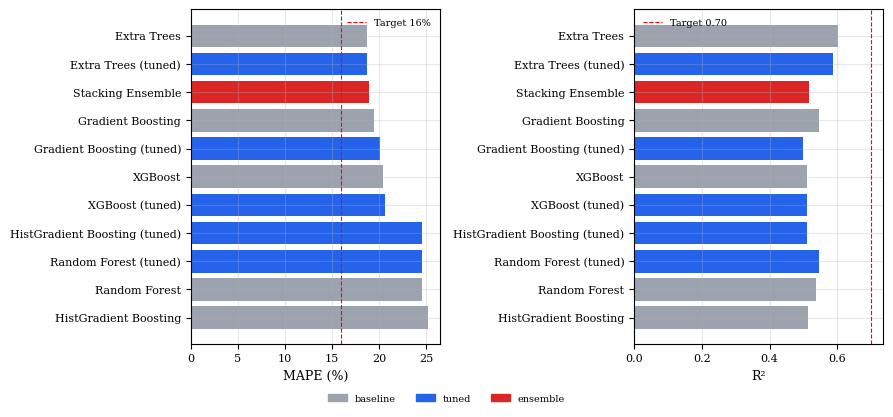

Saved: fig_model_comparison.png


In [13]:
all_results = pd.concat([
    baseline_df[["model", "stage", "rmse", "mae", "mape_pct", "r2"]],
    tuned_df[["model", "stage", "rmse", "mae", "mape_pct", "r2"]],
    pd.DataFrame([stacking_result])[["model", "stage", "rmse", "mae", "mape_pct", "r2"]],
], ignore_index=True).sort_values("mape_pct")

print(all_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
colors = {"baseline": "#9ca3af", "tuned": "#2563eb", "ensemble": "#dc2626"}
color_list = [colors[s] for s in all_results["stage"]]

axes[0].barh(all_results["model"], all_results["mape_pct"], color=color_list)
axes[0].set_xlabel("MAPE (%)")
axes[0].axvline(16, color="red", linewidth=0.8, linestyle="--", label="Target 16%")
axes[0].legend(frameon=False, fontsize=7)
axes[0].invert_yaxis()

axes[1].barh(all_results["model"], all_results["r2"], color=color_list)
axes[1].set_xlabel("R²")
axes[1].axvline(0.70, color="red", linewidth=0.8, linestyle="--", label="Target 0.70")
axes[1].legend(frameon=False, fontsize=7)
axes[1].invert_yaxis()

# legend patches
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           frameon=False, fontsize=7, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig_model_comparison.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_model_comparison.png")

## 14. Select Best Unified Model

In [14]:
best_row = all_results.sort_values(["mape_pct", "rmse"]).iloc[0]
BEST_UNIFIED_NAME = best_row["model"]
print(f"Best unified model: {BEST_UNIFIED_NAME}")
print(f"  RMSE={best_row['rmse']:.3f}  MAPE={best_row['mape_pct']:.3f}%  R²={best_row['r2']:.4f}")

# Resolve pipeline and predictions
if BEST_UNIFIED_NAME == "Stacking Ensemble":
    best_unified_pipe = None  # handled separately
    best_unified_pred = stack_artifact["y_pred"]
    best_unified_metrics = stack_artifact["metrics"]
elif "(tuned)" in BEST_UNIFIED_NAME:
    base_name = BEST_UNIFIED_NAME.replace(" (tuned)", "")
    best_unified_pipe = tuned_artifacts[base_name]["pipe"]
    best_unified_pred = tuned_artifacts[base_name]["y_pred"]
    best_unified_metrics = tuned_artifacts[base_name]["metrics"]
else:
    best_unified_pipe = baseline_artifacts[BEST_UNIFIED_NAME]["pipe"]
    best_unified_pred = baseline_artifacts[BEST_UNIFIED_NAME]["y_pred"]
    best_unified_metrics = baseline_artifacts[BEST_UNIFIED_NAME]["metrics"]

print("\nUnified model metrics on test set:")
for k, v in best_unified_metrics.items():
    print(f"  {k}: {v:.4f}")

Best unified model: Extra Trees
  RMSE=199.494  MAPE=18.702%  R²=0.6020

Unified model metrics on test set:
  rmse: 199.4943
  mae: 38.4402
  mape_pct: 18.7018
  r2: 0.6020


## 15. Device-Specific Model Training

In [15]:
def train_device_model(device_name, df_all, feature_cols, num_feats, cat_feats,
                       target_col=TARGET_COL, random_state=RANDOM_STATE, n_iter=50):
    """Train + tune a device-specific model. Returns (pipeline, scaler, metrics, test_df_with_preds)."""
    dev_df  = df_all[df_all["device_name"] == device_name].copy()
    print(f"\n=== {device_name}: {len(dev_df)} samples ===")

    y_dev = dev_df[target_col].values
    strat = pd.qcut(pd.Series(y_dev), q=4, duplicates="drop").astype(str)

    tr_idx, te_idx = train_test_split(
        np.arange(len(dev_df)), test_size=0.2,
        random_state=random_state, stratify=strat
    )
    Xd     = dev_df[feature_cols].values  # will go through preprocessor
    Xd_df  = dev_df[feature_cols]

    X_tr, X_te = Xd_df.iloc[tr_idx], Xd_df.iloc[te_idx]
    y_tr, y_te = y_dev[tr_idx], y_dev[te_idx]

    # Fit scaler (numeric only, for compatibility with artifact format)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    num_only = [c for c in num_feats if c in dev_df.columns]
    scaler.fit(dev_df[num_only].fillna(dev_df[num_only].median()))

    strat_tr = strat.iloc[tr_idx]
    n_splits_dev = max(3, min(5, int(strat_tr.value_counts().min())))
    cv_dev = StratifiedKFold(n_splits=n_splits_dev, shuffle=True, random_state=random_state)

    base_et  = ExtraTreesRegressor(n_estimators=500, random_state=random_state, n_jobs=-1)
    pipe_et  = make_pipeline(base_et, num_feats=num_feats, cat_feats=cat_feats)

    param_grid_et = {
        "regressor__model__n_estimators":      randint(400, 1200),
        "regressor__model__max_features":      ["sqrt", "log2", 0.5, 0.7, 1.0],
        "regressor__model__min_samples_leaf":  randint(1, 5),
        "regressor__model__min_samples_split": randint(2, 6),
        "regressor__model__max_depth":         [None, 15, 25, 35],
        "regressor__model__bootstrap":         [False, True],
    }

    search = RandomizedSearchCV(
        pipe_et, param_grid_et,
        n_iter=n_iter,
        cv=cv_dev.split(X_tr, strat_tr),
        scoring="neg_root_mean_squared_error",
        random_state=random_state, n_jobs=-1, refit=True,
    )
    search.fit(X_tr, y_tr)
    best_pipe = search.best_estimator_
    print(f"  Best CV RMSE (ET): {-search.best_score_:.3f}")
    print(f"  Best params: {search.best_params_}")

    y_pred_te = best_pipe.predict(X_te)
    m = compute_metrics(y_te, y_pred_te)
    print(f"  Test  RMSE={m['rmse']:.3f}  MAPE={m['mape_pct']:.3f}%  R²={m['r2']:.4f}")

    # Attach predictions to test subset
    te_df = dev_df.iloc[te_idx].copy()
    te_df["prediction"] = y_pred_te
    te_df["residual"]   = y_pred_te - y_te

    return best_pipe, scaler, m, te_df, search.best_params_


jetson_pipe, jetson_scaler, jetson_metrics, jetson_test_df, jetson_best_params = train_device_model(
    "Jetson Nano", df, FEATURE_COLUMNS, NUMERIC_FEATURES, CATEGORICAL_FEATURES
)

rpi5_pipe, rpi5_scaler, rpi5_metrics, rpi5_test_df, rpi5_best_params = train_device_model(
    "Raspberry Pi 5", df, FEATURE_COLUMNS, NUMERIC_FEATURES, CATEGORICAL_FEATURES
)


=== Jetson Nano: 360 samples ===


  Best CV RMSE (ET): 522.040
  Best params: {'regressor__model__bootstrap': False, 'regressor__model__max_depth': None, 'regressor__model__max_features': 1.0, 'regressor__model__min_samples_leaf': 1, 'regressor__model__min_samples_split': 5, 'regressor__model__n_estimators': 480}
  Test  RMSE=162.846  MAPE=22.180%  R²=0.8406

=== Raspberry Pi 5: 253 samples ===


  Best CV RMSE (ET): 9.110
  Best params: {'regressor__model__bootstrap': False, 'regressor__model__max_depth': 25, 'regressor__model__max_features': 0.5, 'regressor__model__min_samples_leaf': 2, 'regressor__model__min_samples_split': 5, 'regressor__model__n_estimators': 977}
  Test  RMSE=6.430  MAPE=12.126%  R²=0.9607


## 16. Diagnostics — Figure 3: Actual vs Predicted (Device Specific)

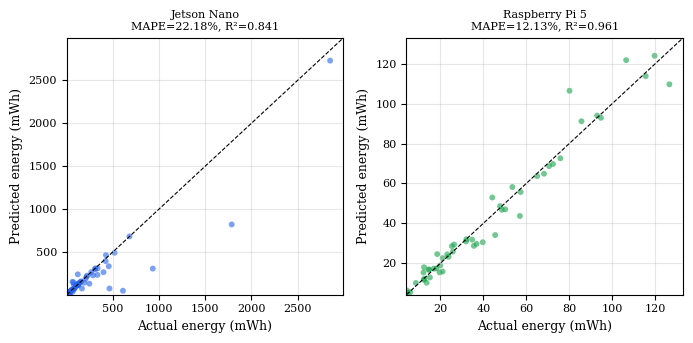

Saved: fig_diagnostics.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, te_df, device, color, metrics in [
    (axes[0], jetson_test_df, "Jetson Nano",     JETSON_COLOR, jetson_metrics),
    (axes[1], rpi5_test_df,  "Raspberry Pi 5",  RPI5_COLOR,   rpi5_metrics),
]:
    y_act  = te_df[TARGET_COL].values
    y_pred = te_df["prediction"].values
    ax.scatter(y_act, y_pred, alpha=0.6, s=18, color=color, edgecolors="none")
    lims = [min(y_act.min(), y_pred.min()) * 0.95,
            max(y_act.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, "k--", linewidth=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual energy (mWh)")
    ax.set_ylabel("Predicted energy (mWh)")
    ax.set_title(f"{device}\nMAPE={metrics['mape_pct']:.2f}%, R²={metrics['r2']:.3f}",
                 fontsize=8)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig_diagnostics.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: fig_diagnostics.png")

## 17. Feature Importance — Figure 4

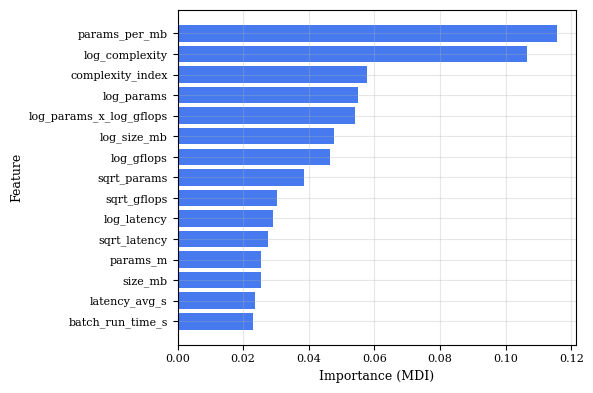

Saved: fig_feature_importance.png

Top 15 features:
                feature  importance
          params_per_mb    0.115590
         log_complexity    0.106365
       complexity_index    0.057606
             log_params    0.055065
log_params_x_log_gflops    0.054053
            log_size_mb    0.047703
             log_gflops    0.046398
            sqrt_params    0.038645
            sqrt_gflops    0.030430
            log_latency    0.029109
           sqrt_latency    0.027622
               params_m    0.025509
                size_mb    0.025398
          latency_avg_s    0.023600
       batch_run_time_s    0.022902


In [17]:
# Use the best tuned Extra Trees model if available, else best unified
if "Extra Trees" in tuned_artifacts:
    fi_pipe = tuned_artifacts["Extra Trees"]["pipe"]
else:
    fi_pipe = best_unified_pipe

if fi_pipe is not None:
    # Extract feature importances from inner pipeline
    inner_pipe = fi_pipe.regressor_  # Pipeline
    prep_fit   = inner_pipe.named_steps["prep"]
    model_fit  = inner_pipe.named_steps["model"]

    # Get transformed feature names
    try:
        num_names  = list(prep_fit.transformers_[0][2])
        ohe_names  = prep_fit.transformers_[1][1].named_steps["ohe"].get_feature_names_out(
            prep_fit.transformers_[1][2]
        ).tolist()
        trans_names = num_names + ohe_names
    except Exception:
        trans_names = [f"f{i}" for i in range(len(model_fit.feature_importances_))]

    importances = model_fit.feature_importances_
    fi_df = pd.DataFrame({"feature": trans_names, "importance": importances})
    fi_df = fi_df.sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color=JETSON_COLOR, alpha=0.85)
    ax.set_xlabel("Importance (MDI)")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig_feature_importance.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: fig_feature_importance.png")
    print("\nTop 15 features:")
    print(fi_df.to_string(index=False))
else:
    print("No tree-based pipeline available for feature importance; using permutation on stacking.")
    # Permutation importance on stacking — simple implementation
    rng = np.random.default_rng(RANDOM_STATE)
    Xt_te = prep_stack.transform(X_test)
    base_rmse = rmse(y_test, stack_artifact["y_pred"])
    deltas = []
    for i in range(Xt_te.shape[1]):
        mat = Xt_te.copy()
        mat[:, i] = rng.permutation(mat[:, i])
        yp = np.clip(np.expm1(stacking_model.predict(mat)), 0, None)
        deltas.append(rmse(y_test, yp) - base_rmse)
    top_idx = np.argsort(deltas)[::-1][:15]
    fi_df = pd.DataFrame({"feature": [f"f{i}" for i in top_idx], "importance": [deltas[i] for i in top_idx]})

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color=JETSON_COLOR)
    ax.set_xlabel("Permutation delta RMSE")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig_feature_importance.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: fig_feature_importance.png")

## 18. Save Device-Specific Artifacts

In [18]:
# Save Jetson model
joblib.dump(jetson_pipe, ARTIFACT_DIR / "jetson_energy_model.pkl")
joblib.dump(jetson_scaler, ARTIFACT_DIR / "jetson_scaler.pkl")
print("Saved: jetson_energy_model.pkl, jetson_scaler.pkl")

# Save RPi5 model
joblib.dump(rpi5_pipe, ARTIFACT_DIR / "rpi5_energy_model.pkl")
joblib.dump(rpi5_scaler, ARTIFACT_DIR / "rpi5_scaler.pkl")
print("Saved: rpi5_energy_model.pkl, rpi5_scaler.pkl")

# device_specific_features.json
feat_json = {
    "numeric_features":     NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "feature_columns":      FEATURE_COLUMNS,
    "target_column":        TARGET_COL,
}
(ARTIFACT_DIR / "device_specific_features.json").write_text(
    json.dumps(feat_json, indent=2), encoding="utf-8"
)
print("Saved: device_specific_features.json")

# device_specific_metadata.json
now_str = datetime.now(timezone.utc).isoformat()

def compute_cv_metrics(pipe, X, y, cv_obj, strat_labels):
    scores = cross_val_score(
        pipe, X, y,
        cv=cv_obj.split(X, strat_labels),
        scoring="neg_root_mean_squared_error", n_jobs=1
    )
    r2s = cross_val_score(
        pipe, X, y,
        cv=cv_obj.split(X, strat_labels),
        scoring="r2", n_jobs=1
    )
    return {
        "cv_rmse_mean": float(-scores.mean()),
        "cv_rmse_std":  float(scores.std()),
        "cv_r2_mean":   float(r2s.mean()),
    }

# Jetson CV metrics
jet_df   = df[df["device_name"] == "Jetson Nano"]
jet_strat = pd.qcut(jet_df[TARGET_COL], q=4, duplicates="drop").astype(str)
jet_cv   = StratifiedKFold(n_splits=min(5, int(jet_strat.value_counts().min())),
                            shuffle=True, random_state=RANDOM_STATE)
jet_cv_m = compute_cv_metrics(jetson_pipe, jet_df[FEATURE_COLUMNS], jet_df[TARGET_COL].values,
                               jet_cv, jet_strat)

# RPi5 CV metrics
rpi_df   = df[df["device_name"] == "Raspberry Pi 5"]
rpi_strat = pd.qcut(rpi_df[TARGET_COL], q=4, duplicates="drop").astype(str)
rpi_cv   = StratifiedKFold(n_splits=min(5, int(rpi_strat.value_counts().min())),
                            shuffle=True, random_state=RANDOM_STATE)
rpi_cv_m = compute_cv_metrics(rpi5_pipe, rpi_df[FEATURE_COLUMNS], rpi_df[TARGET_COL].values,
                               rpi_cv, rpi_strat)

metadata = {
    "training_date": now_str,
    "approach": "energy_prediction_model_multidevice_rewritten",
    "random_seed": RANDOM_STATE,
    "n_samples_total": int(len(df)),
    "feature_count": len(FEATURE_COLUMNS),
    "feature_columns": FEATURE_COLUMNS,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "unified_model": {
        "model_name": BEST_UNIFIED_NAME,
        "test_metrics": best_unified_metrics,
    },
    "jetson_model": {
        "model_name": "Extra Trees (tuned)",
        "n_samples": int(len(jet_df)),
        "test_metrics": jetson_metrics,
        "cv_metrics": jet_cv_m,
        "best_params": {str(k): str(v) for k, v in jetson_best_params.items()},
    },
    "rpi5_model": {
        "model_name": "Extra Trees (tuned)",
        "n_samples": int(len(rpi_df)),
        "test_metrics": rpi5_metrics,
        "cv_metrics": rpi_cv_m,
        "best_params": {str(k): str(v) for k, v in rpi5_best_params.items()},
    },
    "model_comparison": all_results[["model", "stage", "rmse", "mae", "mape_pct", "r2"]].to_dict(orient="records"),
}

(ARTIFACT_DIR / "device_specific_metadata.json").write_text(
    json.dumps(metadata, indent=2, default=str), encoding="utf-8"
)
print("Saved: device_specific_metadata.json")

Saved: jetson_energy_model.pkl, jetson_scaler.pkl
Saved: rpi5_energy_model.pkl, rpi5_scaler.pkl
Saved: device_specific_features.json


Saved: device_specific_metadata.json


## 19. Save Energy Thresholds

In [19]:
thresholds = {}
for dev_key, dev_name in [("jetson_nano", "Jetson Nano"), ("raspberry_pi5", "Raspberry Pi 5")]:
    sub = df[df["device_name"] == dev_name][TARGET_COL]
    thresholds[dev_key] = {
        "p10": float(np.percentile(sub, 10)),
        "p25": float(np.percentile(sub, 25)),
        "p50": float(np.percentile(sub, 50)),
        "p75": float(np.percentile(sub, 75)),
        "p90": float(np.percentile(sub, 90)),
        "recommended_threshold": float(np.percentile(sub, 25)),
        "unit": "mWh",
        "interpretation": "Models below P25 belong to the most energy-efficient top 25%",
    }
thresholds["methodology"] = "Percentiles computed from real benchmark measurements for each device"
thresholds["last_updated"] = now_str

(ARTIFACT_DIR / "energy_thresholds.json").write_text(
    json.dumps(thresholds, indent=2), encoding="utf-8"
)
print("Saved: energy_thresholds.json")
print(json.dumps(thresholds, indent=2))

Saved: energy_thresholds.json
{
  "jetson_nano": {
    "p10": 12.485417400000001,
    "p25": 29.98996075,
    "p50": 98.606651,
    "p75": 226.52004625,
    "p90": 705.1255773000004,
    "recommended_threshold": 29.98996075,
    "unit": "mWh",
    "interpretation": "Models below P25 belong to the most energy-efficient top 25%"
  },
  "raspberry_pi5": {
    "p10": 9.4945386,
    "p25": 17.991197,
    "p50": 31.985519,
    "p75": 64.808209,
    "p90": 94.79486940000001,
    "recommended_threshold": 17.991197,
    "unit": "mWh",
    "interpretation": "Models below P25 belong to the most energy-efficient top 25%"
  },
  "methodology": "Percentiles computed from real benchmark measurements for each device",
  "last_updated": "2026-05-09T16:26:13.569552+00:00"
}


## 20. Save Remaining Artifacts (legacy-compatible)

In [20]:
# Save best unified model as energy_predictor.pkl (legacy)
if best_unified_pipe is not None:
    with open(ARTIFACT_DIR / "energy_predictor.pkl", "wb") as f:
        pickle.dump(best_unified_pipe, f)
    print("Saved: energy_predictor.pkl (unified)")
else:
    # Stacking — save components
    with open(ARTIFACT_DIR / "energy_predictor.pkl", "wb") as f:
        pickle.dump({"stacking_model": stacking_model, "preprocessor": prep_stack}, f)
    print("Saved: energy_predictor.pkl (stacking ensemble)")

# energy_scaler.pkl — unified scaler (numeric features)
unified_scaler = StandardScaler()
unified_scaler.fit(df[NUMERIC_FEATURES].fillna(df[NUMERIC_FEATURES].median()))
with open(ARTIFACT_DIR / "energy_scaler.pkl", "wb") as f:
    pickle.dump(unified_scaler, f)
print("Saved: energy_scaler.pkl")

# feature_names.pkl
with open(ARTIFACT_DIR / "feature_names.pkl", "wb") as f:
    pickle.dump(FEATURE_COLUMNS, f)
print("Saved: feature_names.pkl")

# Save model comparison and test predictions
all_results.to_csv(ARTIFACT_DIR / "energy_prediction_multidevice_comparison.csv", index=False)
print("Saved: energy_prediction_multidevice_comparison.csv")

combined_test = pd.concat([jetson_test_df, rpi5_test_df], ignore_index=True)
combined_test.to_csv(ARTIFACT_DIR / "energy_prediction_multidevice_test_predictions.csv", index=False)
print("Saved: energy_prediction_multidevice_test_predictions.csv")

# feature importance CSV
if 'fi_df' in dir() and fi_df is not None:
    fi_df.to_csv(ARTIFACT_DIR / "energy_prediction_complete_feature_importance.csv", index=False)
    print("Saved: energy_prediction_complete_feature_importance.csv")

Saved: energy_predictor.pkl (unified)
Saved: energy_scaler.pkl
Saved: feature_names.pkl
Saved: energy_prediction_multidevice_comparison.csv
Saved: energy_prediction_multidevice_test_predictions.csv
Saved: energy_prediction_complete_feature_importance.csv


## 21. Summary

In [21]:
print("=" * 70)
print("ENERGY PREDICTION MODEL — FINAL SUMMARY")
print("=" * 70)
print(f"\nDataset: {len(df)} samples ({len(jet_df)} Jetson + {len(rpi_df)} RPi5)")
print(f"Features: {len(FEATURE_COLUMNS)} ({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)")

print("\n--- Unified Model ---")
print(f"  Best model : {BEST_UNIFIED_NAME}")
for k, v in best_unified_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\n--- Jetson Nano (device-specific) ---")
for k, v in jetson_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\n--- Raspberry Pi 5 (device-specific) ---")
for k, v in rpi5_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\n--- Figures saved ---")
for fig_path in sorted(FIGURE_DIR.glob("fig_*.png")):
    print(f"  {fig_path.name}")

print("\n--- Artifacts saved ---")
for art in [
    "jetson_energy_model.pkl", "jetson_scaler.pkl",
    "rpi5_energy_model.pkl",   "rpi5_scaler.pkl",
    "energy_predictor.pkl",    "energy_scaler.pkl",
    "energy_thresholds.json",  "device_specific_metadata.json",
    "device_specific_features.json",
]:
    p = ARTIFACT_DIR / art
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {art}")

print("=" * 70)

ENERGY PREDICTION MODEL — FINAL SUMMARY

Dataset: 613 samples (360 Jetson + 253 RPi5)
Features: 52 (48 numeric + 4 categorical)

--- Unified Model ---
  Best model : Extra Trees
  rmse        : 199.4943
  mae         : 38.4402
  mape_pct    : 18.7018
  r2          : 0.6020

--- Jetson Nano (device-specific) ---
  rmse        : 162.8464
  mae         : 56.0638
  mape_pct    : 22.1797
  r2          : 0.8406

--- Raspberry Pi 5 (device-specific) ---
  rmse        : 6.4299
  mae         : 4.1203
  mape_pct    : 12.1261
  r2          : 0.9607

--- Figures saved ---
  fig_correlation.png
  fig_diagnostics.png
  fig_eda_distribution.png
  fig_feature_importance.png
  fig_model_comparison.png

--- Artifacts saved ---
  [OK] jetson_energy_model.pkl
  [OK] jetson_scaler.pkl
  [OK] rpi5_energy_model.pkl
  [OK] rpi5_scaler.pkl
  [OK] energy_predictor.pkl
  [OK] energy_scaler.pkl
  [OK] energy_thresholds.json
  [OK] device_specific_metadata.json
  [OK] device_specific_features.json
